# Code construction 

## Load packages and scripts

In [24]:
using Pkg
Pkg.activate(".")
Pkg.instantiate()

include("src/preprocessing.jl")
include("src/filtration.jl")
include("src/persistence.jl")
include("src/visualization.jl")

using .Preprocessing
using .Filtration
using .Persistence
using .Visualization

using LinearAlgebra

  Activating project at `~/Slovenie/Topologie/Detecting-Shapes`
  0 dependencies successfully precompiled in 7 seconds. 306 already precompiled.

The following 1 direct dependency failed to precompile:

DetectingShapes 

Error: Missing source file for Base.PkgId(Base.UUID("d4c3e3b0-7a3f-4f2b-9a5c-0f2b7e6a1234"), "DetectingShapes"

In [25]:
# include src files 
include("src/filtration.jl")
import .Filtration
include("src/preprocessing.jl")
import .Preprocessing
include("src/visualization.jl")
import .Visualization
include("src/persistence.jl")
import .Persistence

In [26]:
path = "data/circle/samples/circle_0001.csv"

println("pwd() = ", pwd())
println("abspath(path) = ", abspath(path))
println("isfile(path) = ", isfile(path))

pwd() = /Users/eliotmorin/Slovenie/Topologie/Detecting-Shapes
abspath(path) = /Users/eliotmorin/Slovenie/Topologie/Detecting-Shapes/data/circle/samples/circle_0001.csv
isfile(path) = true


## Loading the dataset

In [27]:
path = "data/circle/samples/circle_0001.csv"
shapes = ["circle", "line_segment", "disk", "ellipsoid"]
path_changes = Dict("line_segment" => "line")
n_pershape = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
n_datapoints = 80

pointclouds = Vector{Any}()
corr_results = String[]

for s in shapes
    for i in n_pershape
        push!(corr_results, s)

    
        if haskey(path_changes, s)
            filename = string(path_changes[s], "_", lpad(i, 4, '0'), ".csv")
        else
            filename = string(s, "_", lpad(i, 4, '0'), ".csv")
        end

    
        path = joinpath("data", s, "samples", filename)
        println("Loading: ", path)

        df = Preprocessing.load_pointcloud_csv(path)
        df = df[1:n_datapoints, :]

        points = [tuple(df[j, :]...) for j in axes(df, 1)]
        push!(pointclouds, points)
    end
end


Loading: data/circle/samples/circle_0001.csv
Loading: data/circle/samples/circle_0002.csv
Loading: data/circle/samples/circle_0003.csv
Loading: data/circle/samples/circle_0004.csv
Loading: data/circle/samples/circle_0005.csv
Loading: data/circle/samples/circle_0006.csv
Loading: data/circle/samples/circle_0007.csv
Loading: data/circle/samples/circle_0008.csv
Loading: data/circle/samples/circle_0009.csv
Loading: data/circle/samples/circle_0010.csv
Loading: data/line_segment/samples/line_0001.csv
Loading: data/line_segment/samples/line_0002.csv
Loading: data/line_segment/samples/line_0003.csv
Loading: data/line_segment/samples/line_0004.csv
Loading: data/line_segment/samples/line_0005.csv
Loading: data/line_segment/samples/line_0006.csv
Loading: data/line_segment/samples/line_0007.csv
Loading: data/line_segment/samples/line_0008.csv
Loading: data/line_segment/samples/line_0009.csv
Loading: data/line_segment/samples/line_0010.csv
Loading: data/disk/samples/disk_0001.csv
Loading: data/disk/

## We Work on the filtration and persistence diagrams

In [28]:
# pointclouds : Vector{Vector{Tuple}}  
pointclouds_proc = Vector{Any}(undef, length(pointclouds))

for (k, S) in enumerate(pointclouds)
    # Convertir Vector{Tuple} -> Matrix N×3
    P = reduce(vcat, [collect(p)' for p in S])

    # Centrer + normaliser
    P = Preprocessing.center_points(P)
    P = Preprocessing.normalize_scale(P)  # max(||p||)=1

    # Revenir en Vector{Tuple} (pour ripserer(S))
    pointclouds_proc[k] = [tuple(P[i,1], P[i,2], P[i,3]) for i in 1:size(P,1)]
end


In [29]:
diagrams = Persistence.create_persistence_diagram(pointclouds_proc, "Ripserer", true)


Create Wasserstein Matrix with the filtration_type Ripserer
n_pointclouds = 40
dim = 3
Compute homology of the pointcloud 1
result computed
Compute homology of the pointcloud 2
result computed
Compute homology of the pointcloud 3
result computed
Compute homology of the pointcloud 4
result computed
Compute homology of the pointcloud 5
result computed
Compute homology of the pointcloud 6
result computed
Compute homology of the pointcloud 7
result computed
Compute homology of the pointcloud 8
result computed
Compute homology of the pointcloud 9
result computed
Compute homology of the pointcloud 10
result computed
Compute homology of the pointcloud 11
result computed
Compute homology of the pointcloud 12
result computed
Compute homology of the pointcloud 13
result computed
Compute homology of the pointcloud 14
result computed
Compute homology of the pointcloud 15
result computed
Compute homology of the pointcloud 16
result computed
Compute homology of the pointcloud 17
result computed
Comp

40-element Vector{Any}:
 PersistenceDiagrams.PersistenceDiagram[80-element 0-dimensional PersistenceDiagram, 1-element 1-dimensional PersistenceDiagram, 7-element 2-dimensional PersistenceDiagram]
 PersistenceDiagrams.PersistenceDiagram[80-element 0-dimensional PersistenceDiagram, 1-element 1-dimensional PersistenceDiagram, 9-element 2-dimensional PersistenceDiagram]
 PersistenceDiagrams.PersistenceDiagram[80-element 0-dimensional PersistenceDiagram, 1-element 1-dimensional PersistenceDiagram, 9-element 2-dimensional PersistenceDiagram]
 PersistenceDiagrams.PersistenceDiagram[80-element 0-dimensional PersistenceDiagram, 1-element 1-dimensional PersistenceDiagram, 9-element 2-dimensional PersistenceDiagram]
 PersistenceDiagrams.PersistenceDiagram[80-element 0-dimensional PersistenceDiagram, 1-element 1-dimensional PersistenceDiagram, 7-element 2-dimensional PersistenceDiagram]
 PersistenceDiagrams.PersistenceDiagram[80-element 0-dimensional PersistenceDiagram, 1-element 1-dimensional Pe

In [30]:
println(" First cercle H0 : ", diagrams[1][1])
println("First cercle H1 : ", diagrams[1][2])
println("First line_segment H0 : ", diagrams[11][1])
println("First line_segment H1 : ", diagrams[11][2])

 First cercle H0 : 80-element 0-dimensional PersistenceDiagram
First cercle H1 : 1-element 1-dimensional PersistenceDiagram
First line_segment H0 : 80-element 0-dimensional PersistenceDiagram
First line_segment H1 : 1-element 1-dimensional PersistenceDiagram


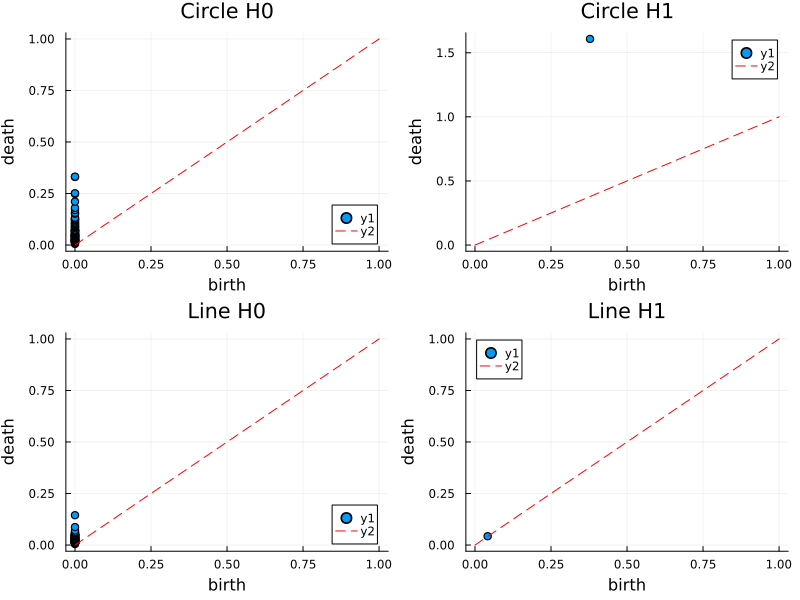

In [31]:

using Plots

circle_h0 = diagrams[1][1]
circle_h1 = diagrams[1][2] 
line_h0 = diagrams[11][1]
line_h1 = diagrams[11][2]

# Plot basique
p1 = plot([p.birth for p in circle_h0], [p.death for p in circle_h0], 
    seriestype=:scatter, title="Circle H0", xlabel="birth", ylabel="death")
plot!(p1, [0, 1], [0, 1], line=:dash, color=:red)

p2 = plot([p.birth for p in circle_h1], [p.death for p in circle_h1], 
    seriestype=:scatter, title="Circle H1", xlabel="birth", ylabel="death")
plot!(p2, [0, 1], [0, 1], line=:dash, color=:red)

p3 = plot([p.birth for p in line_h0], [p.death for p in line_h0], 
    seriestype=:scatter, title="Line H0", xlabel="birth", ylabel="death")
plot!(p3, [0, 1], [0, 1], line=:dash, color=:red)

p4 = plot([p.birth for p in line_h1], [p.death for p in line_h1], 
    seriestype=:scatter, title="Line H1", xlabel="birth", ylabel="death")
plot!(p4, [0, 1], [0, 1], line=:dash, color=:red)

plot(p1, p2, p3, p4, layout=(2,2), size=(800,600))

In [32]:
@show length(diagrams)     
@show length(diagrams[1])    

length(diagrams) = 40
length(diagrams[1]) = 3


3

## We Use wasserstein to clsuter and make KNN classification

In [33]:
Ds = Persistence.create_wasserstein_matrix(diagrams)

3-element Vector{Matrix{Float64}}:
 [0.0 0.5371625702851797 … 4.494741699496042 4.482159355757597; 0.5371625702851797 0.0 … 4.782318376983206 4.701379125563331; … ; 4.494741699496042 4.782318376983206 … 0.0 0.9862376551133631; 4.482159355757597 4.701379125563331 … 0.9862376551133631 0.0]
 [0.0 0.11398917985178914 … 1.2169817620105696 1.3547127733130797; 0.11398917985178914 0.0 … 1.1722412849651322 1.3099722962676423; … ; 1.2169817620105696 1.1722412849651322 … 0.0 0.5608732458687778; 1.3547127733130797 1.3099722962676423 … 0.5608732458687778 0.0]
 [0.0 0.16372980951073046 … 0.1363401867559536 0.16739424213691334; 0.16372980951073046 0.0 … 0.11296537008105434 0.14401942546201407; … ; 0.1363401867559536 0.11296537008105434 … 0.0 0.08483373506389946; 0.16739424213691334 0.14401942546201407 … 0.08483373506389946 0.0]

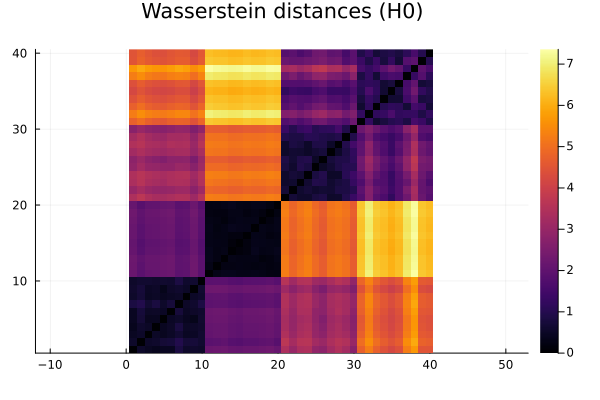

In [34]:
heatmap(Ds[1], aspect_ratio=:equal, title="Wasserstein distances (H0)")

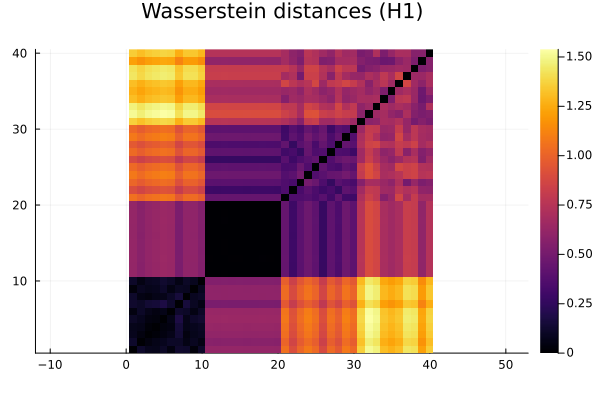

In [35]:
heatmap(Ds[2], aspect_ratio=:equal, title="Wasserstein distances (H1)")

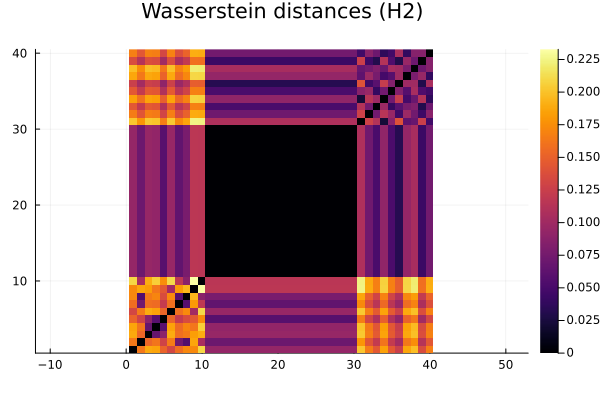

In [36]:
heatmap(Ds[3], aspect_ratio=:equal, title="Wasserstein distances (H2)")

In [37]:
corr_results


40-element Vector{String}:
 "circle"
 "circle"
 "circle"
 "circle"
 "circle"
 "circle"
 "circle"
 "circle"
 "circle"
 "circle"
 ⋮
 "ellipsoid"
 "ellipsoid"
 "ellipsoid"
 "ellipsoid"
 "ellipsoid"
 "ellipsoid"
 "ellipsoid"
 "ellipsoid"
 "ellipsoid"

## We do cluster 

In [38]:
using Clustering
using StatsPlots

results_clustering = []
for D in Ds
    rc = hclust(D; linkage=:average)
    push!(results_clustering, rc)
end

clusters = []
for r in results_clustering
    push!(clusters, cutree(r; k=length(shapes)))
end

In [39]:
for hi in 1:length(clusters)
    println("\nResults for H_", hi)
    for c in 1:length(shapes)
        println("Cluster $c ---------")
        println(corr_results[clusters[hi] .== c])
    end
end


Results for H_1
Cluster 1 ---------
["circle", "circle", "circle", "circle", "circle", "circle", "circle", "circle", "circle", "circle"]
Cluster 2 ---------
["line_segment", "line_segment", "line_segment", "line_segment", "line_segment", "line_segment", "line_segment", "line_segment", "line_segment", "line_segment"]
Cluster 3 ---------
["disk", "disk", "disk", "disk", "disk", "disk", "disk", "disk", "disk", "disk"]
Cluster 4 ---------
["ellipsoid", "ellipsoid", "ellipsoid", "ellipsoid", "ellipsoid", "ellipsoid", "ellipsoid", "ellipsoid", "ellipsoid", "ellipsoid"]

Results for H_2
Cluster 1 ---------
["circle", "circle", "circle", "circle", "circle", "circle", "circle", "circle", "circle", "circle"]
Cluster 2 ---------
["line_segment", "line_segment", "line_segment", "line_segment", "line_segment", "line_segment", "line_segment", "line_segment", "line_segment", "line_segment", "disk", "disk", "disk", "disk", "disk", "disk", "disk", "disk", "disk", "disk"]
Cluster 3 ---------
["ellipsoi

## We used KNN classification

In [40]:

 function combine_distances(Ds::Vector{<:AbstractMatrix}, weights::AbstractVector{<:Real})
    @assert length(Ds) == length(weights)
    n = size(Ds[1], 1)
    D = zeros(Float64, n, n)
    for (hi, w) in enumerate(weights)
        @assert size(Ds[hi], 1) == n && size(Ds[hi], 2) == n
        D .+= w .* Ds[hi]
    end
    return D
end

#k-NN: predcit the element  (leave-one-out)
function knn_predict_index(D::AbstractMatrix, labels::Vector{String}, i::Int; k::Int=5)
    n = size(D, 1)
    @assert length(labels) == n
    @assert 1 <= i <= n
    @assert k < n

    idxs = collect(1:n)
    deleteat!(idxs, i)                # exclure i
    sorted = sort(idxs, by=j -> D[i,j])
    nn = sorted[1:k]

    counts = Dict{String, Int}()
    for j in nn
        counts[labels[j]] = get(counts, labels[j], 0) + 1
    end

    # tie-break: si draw , class with the lower distance 
    best_label = ""
    best_count = -1
    best_sumdist = Inf
    for (lab, c) in counts
        s = sum(D[i,j] for j in nn if labels[j] == lab)
        if (c > best_count) || (c == best_count && s < best_sumdist)
            best_label = lab
            best_count = c
            best_sumdist = s
        end
    end

    return best_label
end

# Evaluation leave-one-out (LOO)
function knn_leave_one_out(D::AbstractMatrix, labels::Vector{String}; k::Int=5)
    n = size(D, 1)
    correct = 0
    errors = Tuple{Int,String,String}[]
    for i in 1:n
        pred = knn_predict_index(D, labels, i; k=k)
        if pred == labels[i]
            correct += 1
        else
            push!(errors, (i, labels[i], pred))
        end
    end
    return correct/n, errors
end


knn_leave_one_out (generic function with 1 method)

In [41]:
weights = [0.5, 3.0, 0.5]   # ajuste si besoin
Dcomb = combine_distances(Ds, weights)

40×40 Matrix{Float64}:
 0.0       0.692414  0.534021  …  7.02677  7.2131   5.96649  6.38892
 0.692414  0.0       0.457002     7.00734  7.19711  5.96437  6.35262
 0.534021  0.457002  0.0          7.00931  7.21992  5.99905  6.38662
 0.487834  0.546442  0.34113      7.00529  7.21743  5.99659  6.37306
 0.594009  0.637961  0.370182     7.02258  7.2495   6.01002  6.39118
 0.397352  0.757779  0.534196  …  7.08577  7.29903  6.04645  6.45292
 0.8493    0.813374  0.804668     6.77625  7.02373  5.75943  6.1474
 0.695818  0.538821  0.42502      6.99462  7.21218  5.99198  6.37085
 0.45816   0.711539  0.536201     6.85467  7.09255  5.83829  6.22225
 0.704098  0.503872  0.65601      6.88971  7.05762  5.83809  6.2302
 ⋮                             ⋱                             
 7.23632   7.23339   7.26117      2.79741  2.32269  2.01652  2.28128
 6.87049   6.85882   6.86227      2.38928  2.52416  2.20762  2.54154
 6.22733   6.208     6.24757      3.08496  2.89315  1.82673  2.02086
 5.99313   5.97794  

In [42]:
acc, errors = knn_leave_one_out(Dcomb, corr_results; k=5)
println("LOO accuracy = ", acc)
println("Nb erreurs = ", length(errors))
errors

LOO accuracy = 1.0
Nb erreurs = 0


Tuple{Int64, String, String}[]

## We use Dentograms 

In [43]:

using Clustering, StatsPlots, Plots

hc_H0 = hclust(Ds[1]; linkage=:average)

n_per_shape = length(n_pershape)
shape_colors = [:blue, :red, :green, :orange]
tick_labels = String[]
tick_colors = Int[]

for (i, shape) in enumerate(shapes)
    for j in 1:n_per_shape
        push!(tick_labels, "$(shape[1:3])_$j")
        push!(tick_colors, i)
    end
end

p = plot(hc_H0, title="Dendrogramme H0 ($(n_datapoints) points)", 
         xticks=(1:length(corr_results), tick_labels),
         xrotation=45, size=(800,500))

# Sauvegarder
mkpath("results/plots")
savefig(p, "results/plots/dendrogram_H0_$(n_datapoints)pts.png")

"/Users/eliotmorin/Slovenie/Topologie/Detecting-Shapes/results/plots/dendrogram_H0_80pts.png"